In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("datasets/dp_lms_student_analytics_dataset.csv")

<Figure size 1000x500 with 0 Axes>

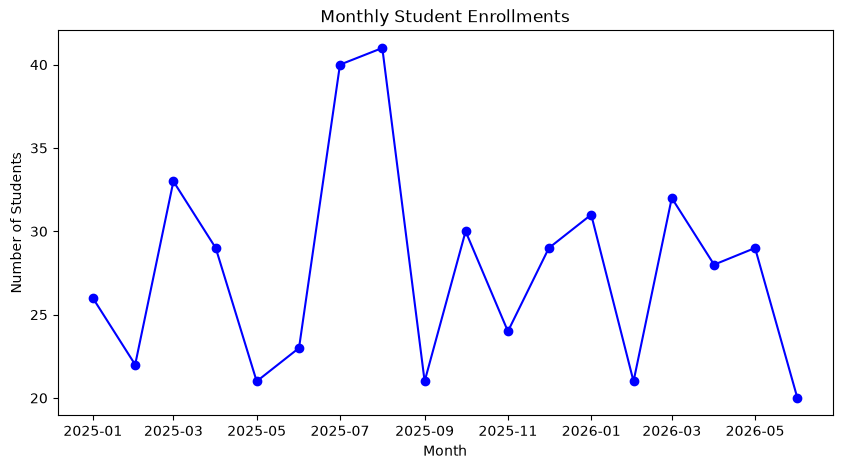

In [32]:
#Monthly student Enrollments
plt.figure(figsize=(10, 5))
df['EnrollmentDate'] = pd.to_datetime(df['EnrollmentDate'])
df['Month'] = df['EnrollmentDate'].dt.to_period('M').dt.to_timestamp()
plt.figure(figsize=(10, 5))
monthly_enrollments = df.groupby('Month').size()
plt.plot(monthly_enrollments.index, monthly_enrollments.values, marker='o', color='b')
plt.title('Monthly Student Enrollments')
plt.xlabel('Month')
plt.ylabel('Number of Students')
plt.show()

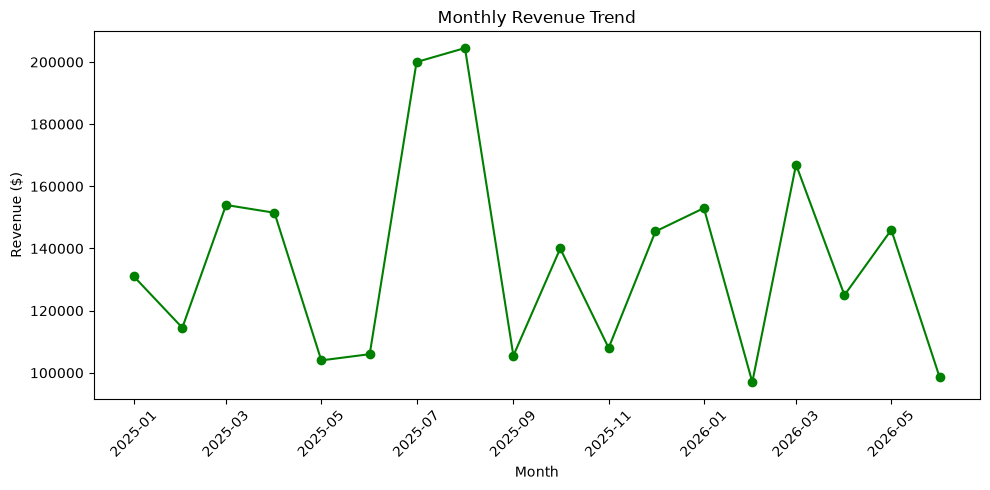

In [16]:
#Monthly Revenue Trend
plt.figure(figsize=(10, 5))
monthly_revenue = df.groupby('Month')['CourseFee'].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='g')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

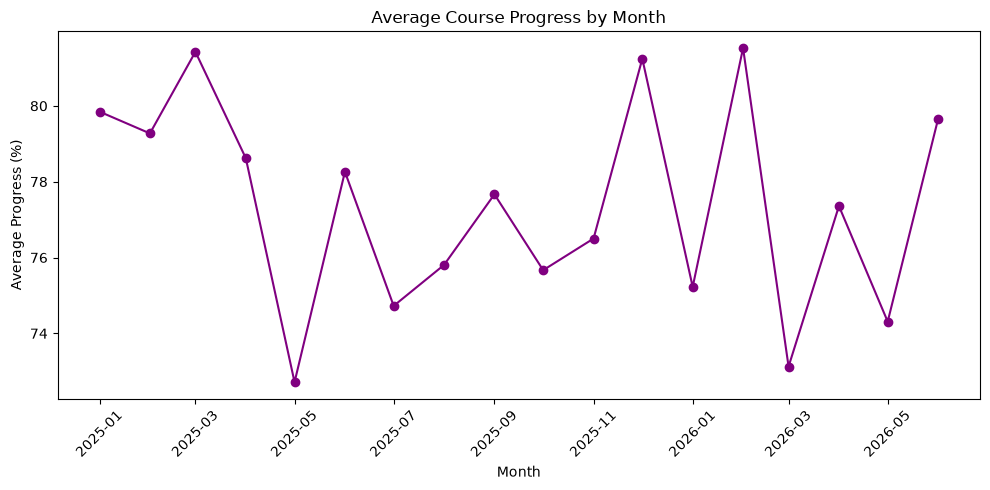

In [17]:
#Average Courses Progress by Month
plt.figure(figsize=(10, 5))
monthly_progress = df.groupby('Month')['CourseProgress'].mean()
plt.plot(monthly_progress.index, monthly_progress.values, marker='o', color='purple')
plt.title('Average Course Progress by Month')
plt.xlabel('Month')
plt.ylabel('Average Progress (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

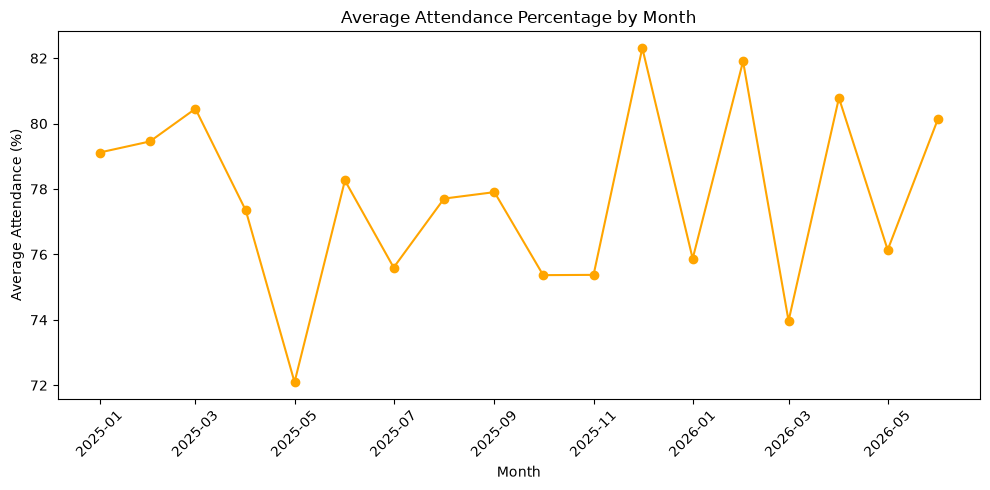

In [18]:
#Average Attendance Percentage by Month
plt.figure(figsize=(10, 5))
monthly_attendance = df.groupby('Month')['AttendancePercentage'].mean()
plt.plot(monthly_attendance.index, monthly_attendance.values, marker='o', color='orange')
plt.title('Average Attendance Percentage by Month')
plt.xlabel('Month')
plt.ylabel('Average Attendance (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

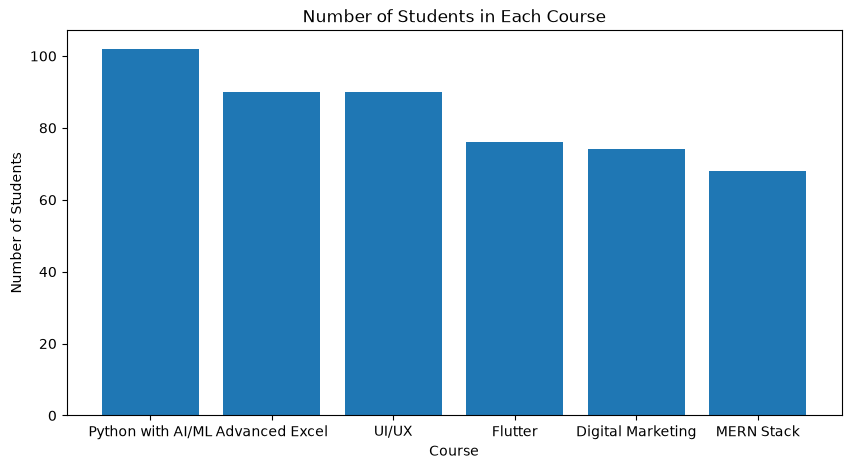

In [29]:
#Number of students in Each Course
plt.figure(figsize=(10, 5))
course_counts = df['Course'].value_counts()
plt.bar(course_counts.index, course_counts.values)
plt.title('Number of Students in Each Course')
plt.xlabel('Course')
plt.ylabel('Number of Students')
plt.show()

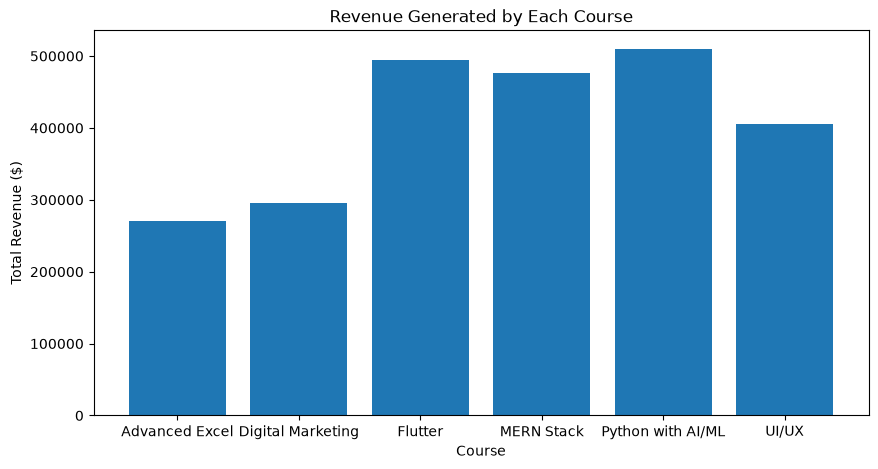

In [28]:
#Revenue Generated by Each Course
plt.figure(figsize=(10, 5))
course_rev = df.groupby('Course')['CourseFee'].sum()
plt.bar(course_rev.index, course_rev.values)
plt.title('Revenue Generated by Each Course')
plt.xlabel('Course')
plt.ylabel('Total Revenue ($)')
plt.show()

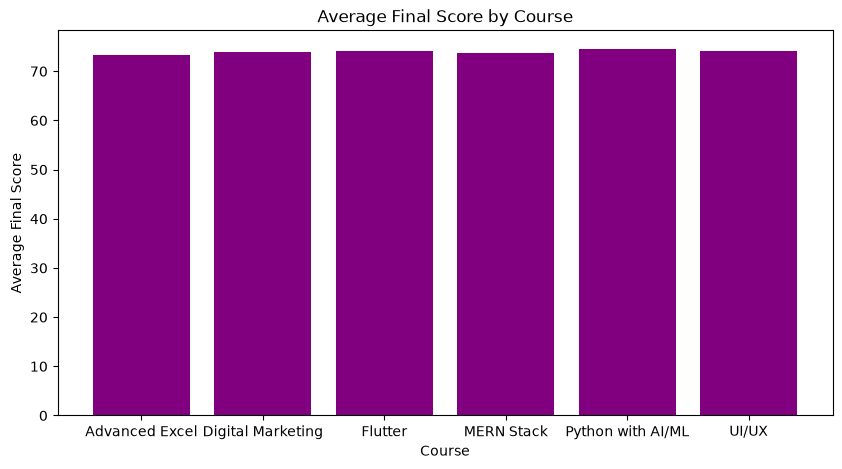

In [31]:
#Average Final Score by Course
plt.figure(figsize=(10, 5))
course_avg_score = df.groupby('Course')['FinalScore'].mean()
plt.bar(course_avg_score.index, course_avg_score.values, color='purple')
plt.title('Average Final Score by Course')
plt.xlabel('Course')
plt.ylabel('Average Final Score')
plt.show()

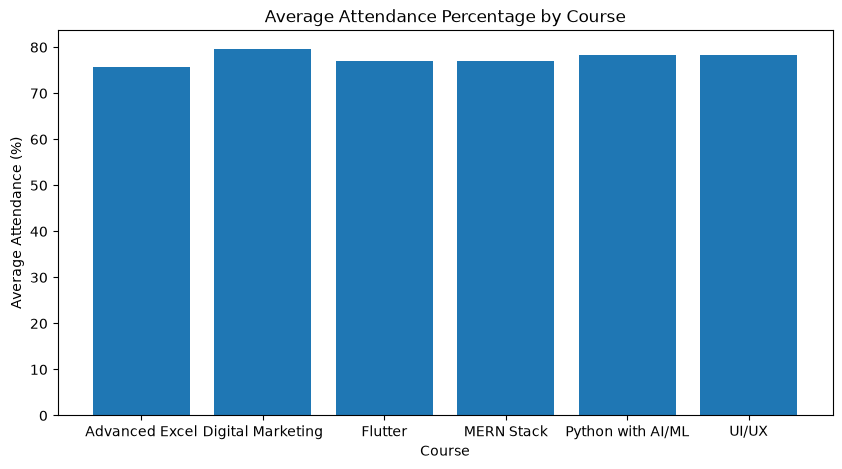

In [35]:
#Average Attendance Percentage by Course
plt.figure(figsize=(10, 5))
course_avg_att = df.groupby('Course')['AttendancePercentage'].mean()
plt.bar(course_avg_att.index, course_avg_att.values)
plt.title('Average Attendance Percentage by Course')
plt.xlabel('Course')
plt.ylabel('Average Attendance (%)')
plt.show()

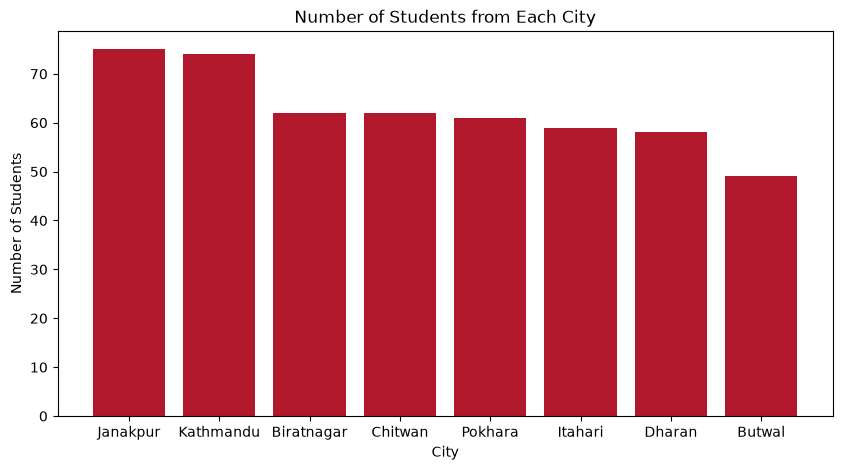

In [34]:
# 5. Number of students from each city
plt.figure(figsize=(10, 5))
city_counts = df['City'].value_counts()
plt.bar(city_counts.index, city_counts.values, color='#b2182b')
plt.title('Number of Students from Each City')
plt.xlabel('City')
plt.ylabel('Number of Students')
plt.show()

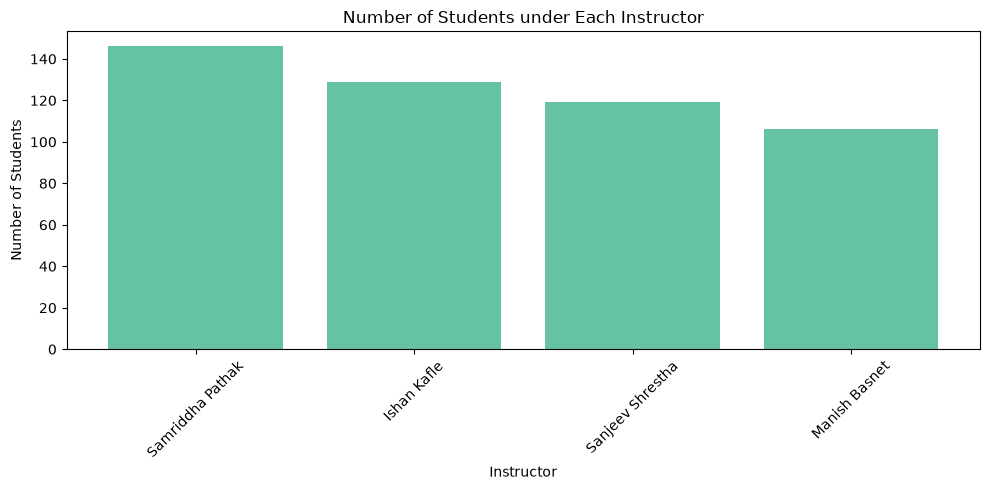

In [33]:
# 6. Number of students under each instructor
plt.figure(figsize=(10, 5))
instructor_counts = df['Instructor'].value_counts()
plt.bar(instructor_counts.index, instructor_counts.values, color='#66c2a5')
plt.title('Number of Students under Each Instructor')
plt.xlabel('Instructor')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

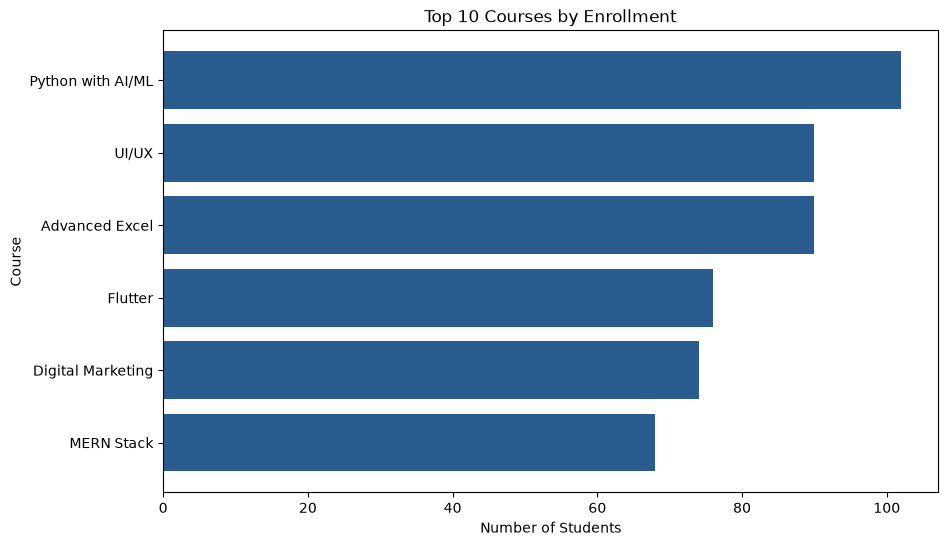

In [36]:
# 1. Top 10 courses by enrollment
plt.figure(figsize=(10, 6))
top_courses = df['Course'].value_counts().head(10).sort_values(ascending=True)
plt.barh(top_courses.index, top_courses.values, color='#2b5c8f')
plt.title('Top 10 Courses by Enrollment')
plt.xlabel('Number of Students')
plt.ylabel('Course')
plt.show()


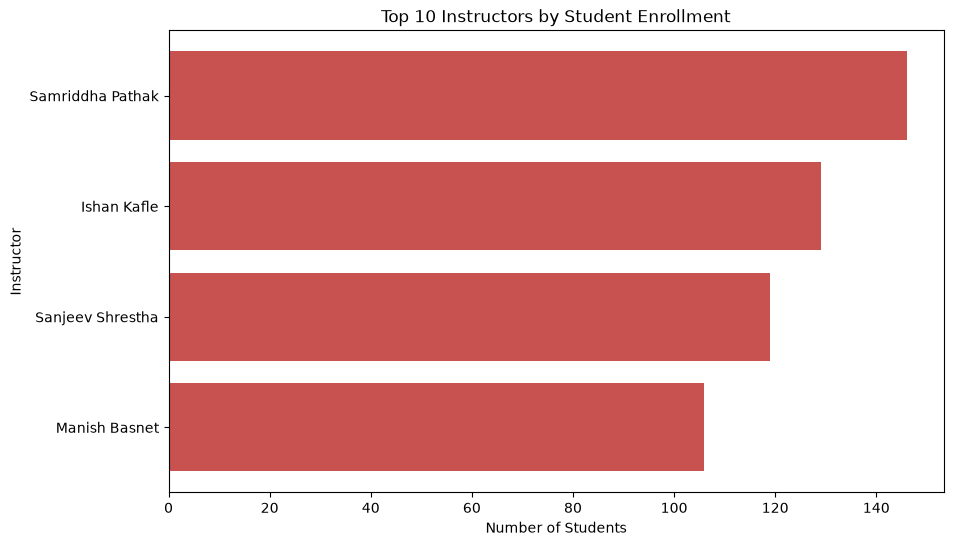

In [37]:

# 2. Top 10 instructors by student enrollment
plt.figure(figsize=(10, 6))
top_instructors = df['Instructor'].value_counts().head(10).sort_values(ascending=True)
plt.barh(top_instructors.index, top_instructors.values, color='#c85250')
plt.title('Top 10 Instructors by Student Enrollment')
plt.xlabel('Number of Students')
plt.ylabel('Instructor')
plt.show()


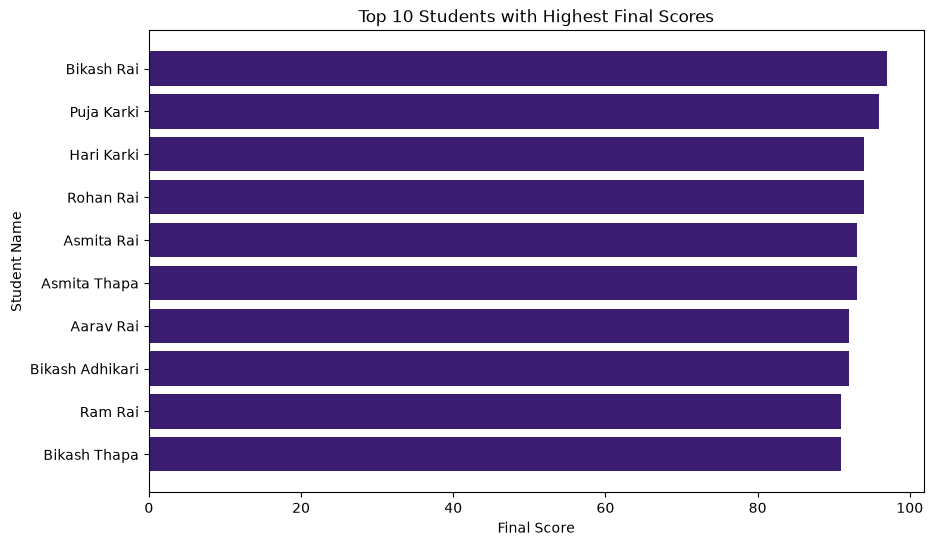

In [42]:

# 3. Top 10 students with the highest final scores
plt.figure(figsize=(10, 6))
top_students = df.nlargest(10, 'FinalScore').sort_values('FinalScore', ascending=True)
plt.barh(top_students['StudentName'], top_students['FinalScore'], color='#3a1c71')
plt.title('Top 10 Students with Highest Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Student Name')
plt.show()

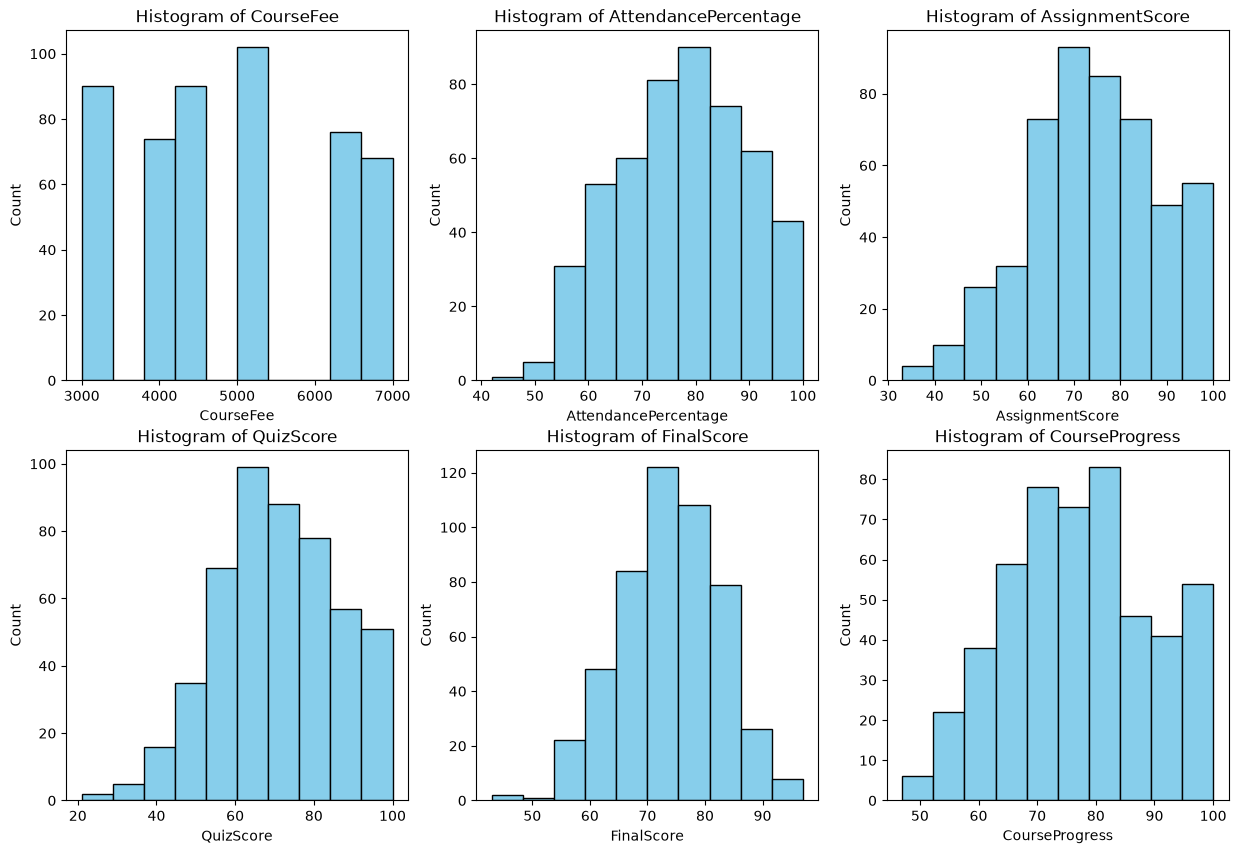

In [4]:
hist_columns = [
    'CourseFee', 
    'AttendancePercentage', 
    'AssignmentScore', 
    'QuizScore', 
    'FinalScore', 
    'CourseProgress'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(hist_columns, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=10, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.show()

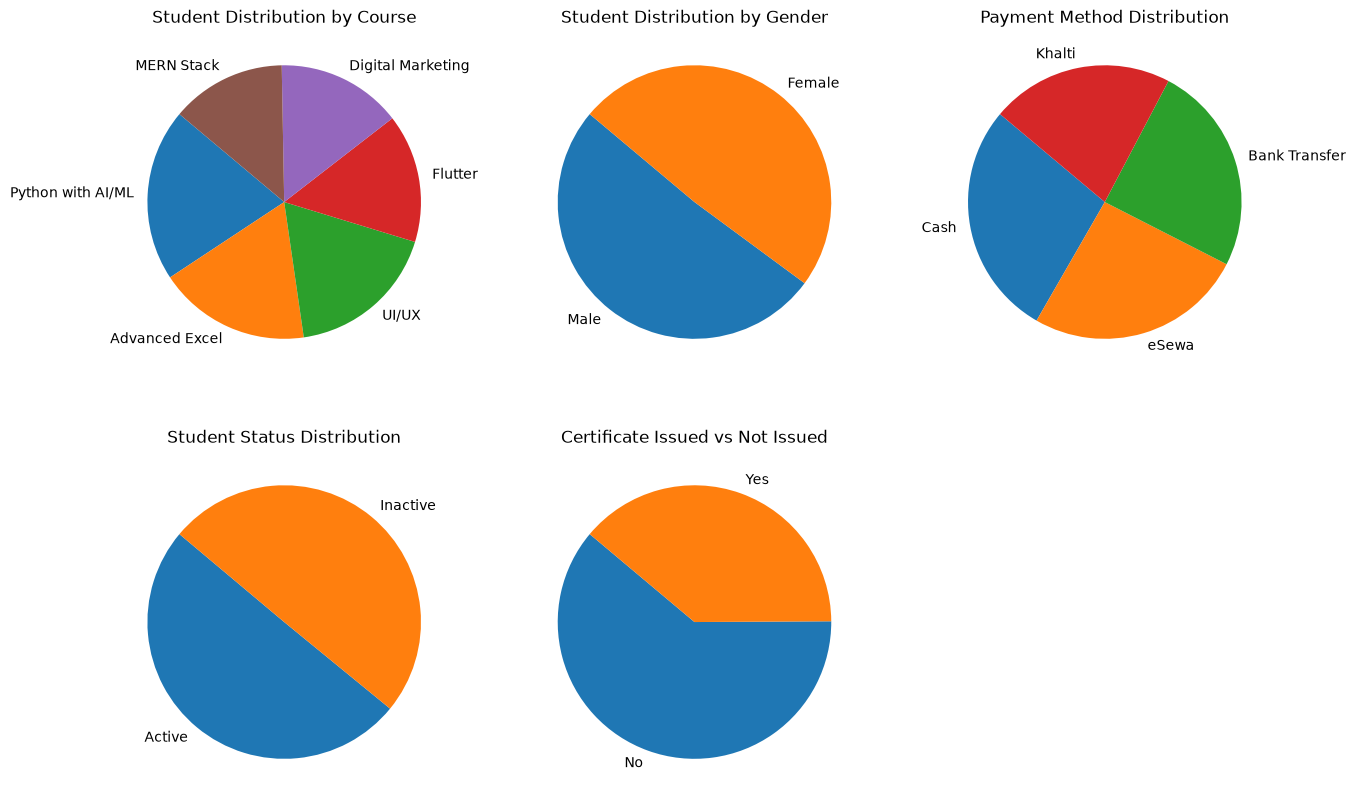

In [7]:
pie_columns = [
    ('Course', 'Student Distribution by Course'),
    ('Gender', 'Student Distribution by Gender'),
    ('PaymentMethod', 'Payment Method Distribution'),
    ('StudentStatus', 'Student Status Distribution'),
    ('CertificateIssued', 'Certificate Issued vs Not Issued')
]

plt.figure(figsize=(15, 10))

for i, (col, title) in enumerate(pie_columns, 1):
    plt.subplot(2, 3, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, startangle=140)
    plt.title(title)
plt.show()

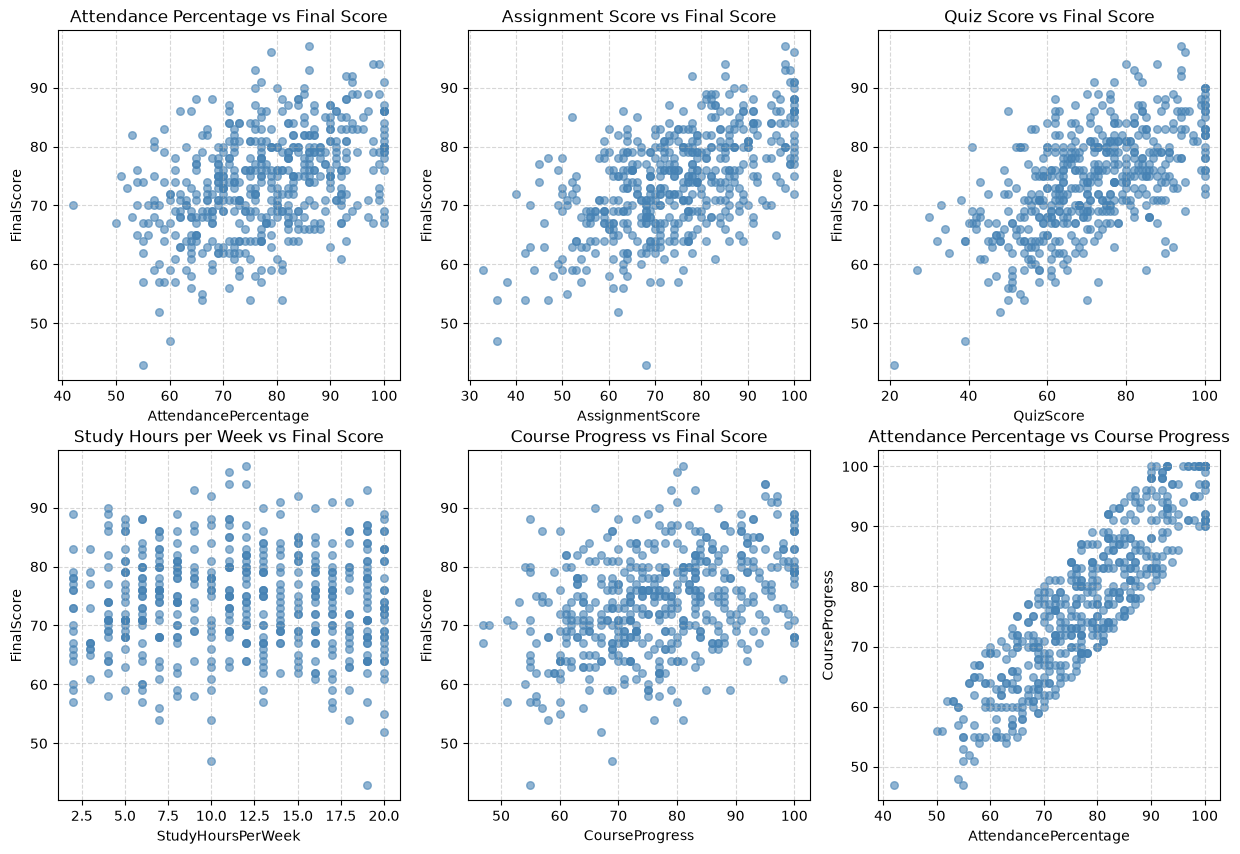

In [8]:
scatter_pairs = [
    ('AttendancePercentage', 'FinalScore', 'Attendance Percentage vs Final Score'),
    ('AssignmentScore', 'FinalScore', 'Assignment Score vs Final Score'),
    ('QuizScore', 'FinalScore', 'Quiz Score vs Final Score'),
    ('StudyHoursPerWeek', 'FinalScore', 'Study Hours per Week vs Final Score'),
    ('CourseProgress', 'FinalScore', 'Course Progress vs Final Score'),
    ('AttendancePercentage', 'CourseProgress', 'Attendance Percentage vs Course Progress')
]

plt.figure(figsize=(15, 10))

for i, (x_col, y_col, title) in enumerate(scatter_pairs, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[x_col], df[y_col], alpha=0.6, color='steelblue', s=30)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, linestyle='--', alpha=0.5)
plt.show()